# Robustness to test-time image degradation

This study keeps all six trained models fixed and degrades only the 5,000 test images. It evaluates Gaussian noise, Gaussian blur, horizontal motion blur, and JPEG compression at four severity levels, plus a clean baseline.

In [26]:
from pathlib import Path
import json
import pandas as pd
from PIL import Image
from IPython.display import display

start = Path.cwd().resolve()
workspace = next((p for p in (start, *start.parents) if (p / 'reproduction').is_dir()), None)
if workspace is None:
    raise RuntimeError('Could not locate the workspace root')
run_dir = workspace / 'reproduction' / 'outputs' / 'deep' / 'robustness_v1'
analysis_dir = workspace / 'reproduction' / 'outputs' / 'deep' / 'robustness_analysis_v1'
print('Run:', run_dir)
print('Analysis:', analysis_dir)

Run: C:\Users\17111\COMP9517GROUP_SUBJECT\reproduction\outputs\deep\robustness_v1
Analysis: C:\Users\17111\COMP9517GROUP_SUBJECT\reproduction\outputs\deep\robustness_analysis_v1


## Protocol validation

The metadata must report a completed run with no training or checkpoint updates. Every model is evaluated on the same class mapping and the same 5,000 test images.

In [27]:
metadata = json.loads((run_dir / 'run_metadata.json').read_text(encoding='utf-8'))
metrics = pd.read_csv(run_dir / 'robustness_metrics.csv')
assert metadata['status'] == 'completed'
assert len(metrics) == 6 * 17
assert set(metrics['images']) == {5000}
display(pd.Series({k: v for k, v in metadata.items() if k != 'conditions'}, name='value').to_frame())

,value
status,completed
device,cuda
seed,0
dataset,C:\Users\17111\COMP9517GROUP_SUBJECT\data\inat...
checkpoints,C:\Users\17111\COMP9517GROUP_SUBJECT\data\mode...
batch_size,32
workers,2
max_images,None
models,"[inat_alexnet_500_npclasses_imagenet.pth, inat..."
completed_conditions,102


## Clean baseline

The clean condition verifies that the evaluation pipeline reproduces the expected fixed-model test performance before any degradation is applied.

In [28]:
clean = metrics[metrics['degradation'] == 'clean'][['model', 'top1_accuracy', 'macro_f1']]
display(clean.sort_values('top1_accuracy', ascending=False).style.format({'top1_accuracy': '{:.2%}', 'macro_f1': '{:.2%}'}))

,model,top1_accuracy,macro_f1
85,ResNet50 pretrained,77.70%,77.64%
51,ResNet18 pretrained,71.02%,70.93%
17,AlexNet pretrained,52.06%,51.18%
34,ResNet18 random,37.24%,36.62%
68,ResNet50 random,34.22%,33.72%
0,AlexNet random,16.16%,15.68%


## Robustness ranking

Absolute robustness ranks models by mean corrupted Top-1 accuracy. Relative robustness ranks them by the fraction of clean accuracy retained. A weak clean model can have a high relative retention while remaining unusable in absolute terms, so both views are reported.

In [29]:
summary = pd.read_csv(analysis_dir / 'model_robustness_summary.csv')
display(summary.style.format({column: '{:.2%}' for column in summary.columns if column not in {'model', 'absolute_robustness_rank', 'relative_robustness_rank'}}))

,model,clean_top1_accuracy,clean_macro_f1,mean_corrupted_top1,mean_corrupted_macro_f1,mean_top1_drop,mean_macro_f1_drop,mean_relative_top1_retention,mean_relative_f1_retention,absolute_robustness_rank,relative_robustness_rank
0,ResNet50 pretrained,77.70%,77.64%,53.40%,53.74%,24.30%,23.89%,68.73%,69.22%,1,2
1,ResNet18 pretrained,71.02%,70.93%,45.58%,45.87%,25.44%,25.06%,64.18%,64.66%,2,3
2,AlexNet pretrained,52.06%,51.18%,32.18%,31.81%,19.88%,19.37%,61.81%,62.16%,3,6
3,ResNet18 random,37.24%,36.62%,23.08%,22.33%,14.16%,14.28%,61.98%,60.99%,4,5
4,ResNet50 random,34.22%,33.72%,21.62%,21.16%,12.60%,12.56%,63.18%,62.75%,5,4
5,AlexNet random,16.16%,15.68%,11.97%,11.24%,4.19%,4.44%,74.06%,71.69%,6,1


## Performance-versus-severity curves

Each curve begins at the model's clean baseline and then shows four increasing severity levels.

gaussian_blur_macro_f1


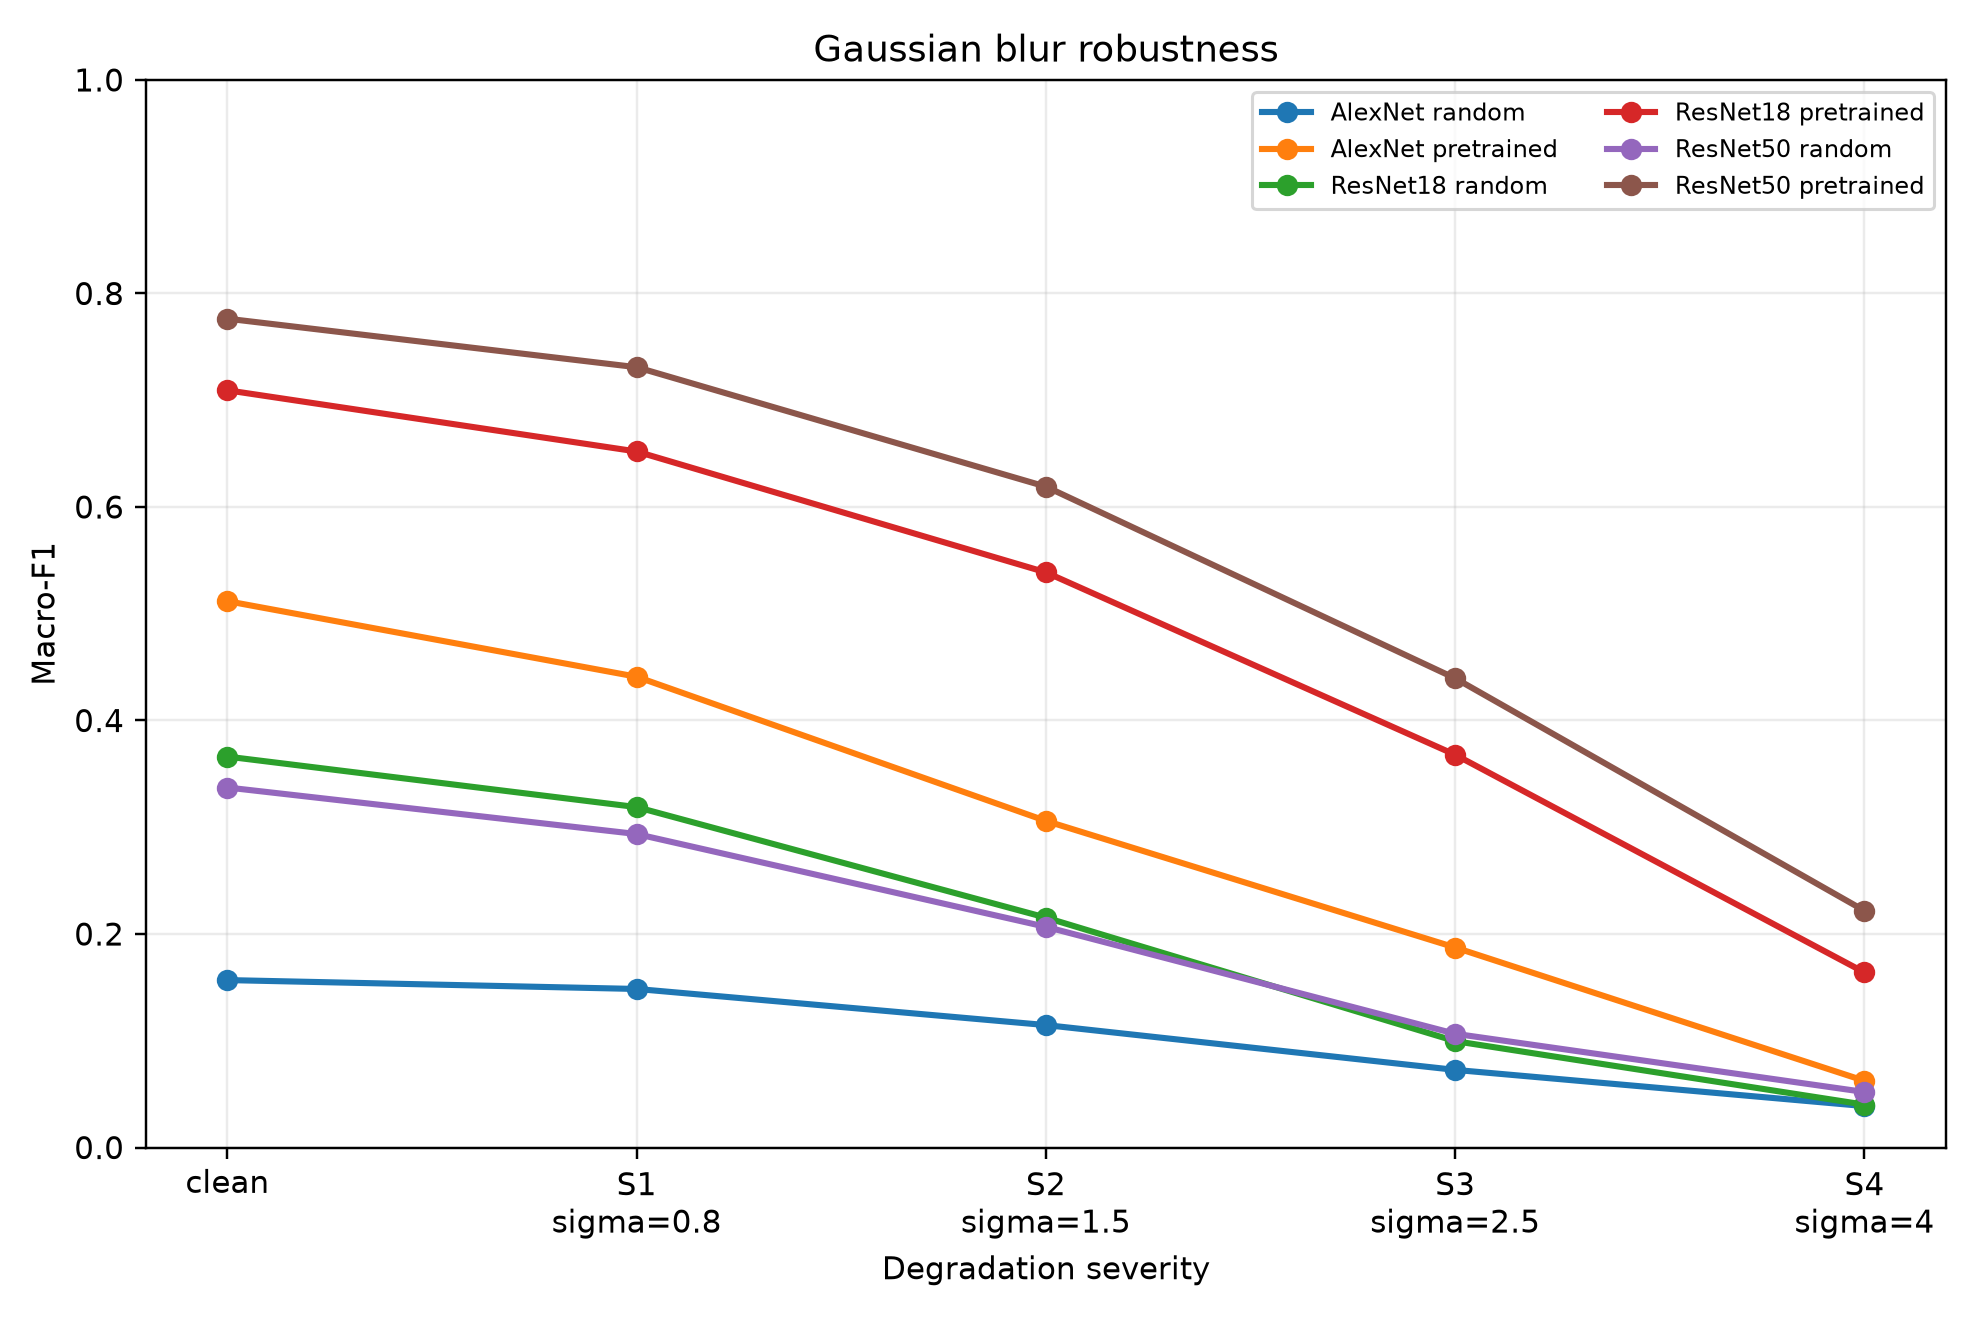

gaussian_blur_top1


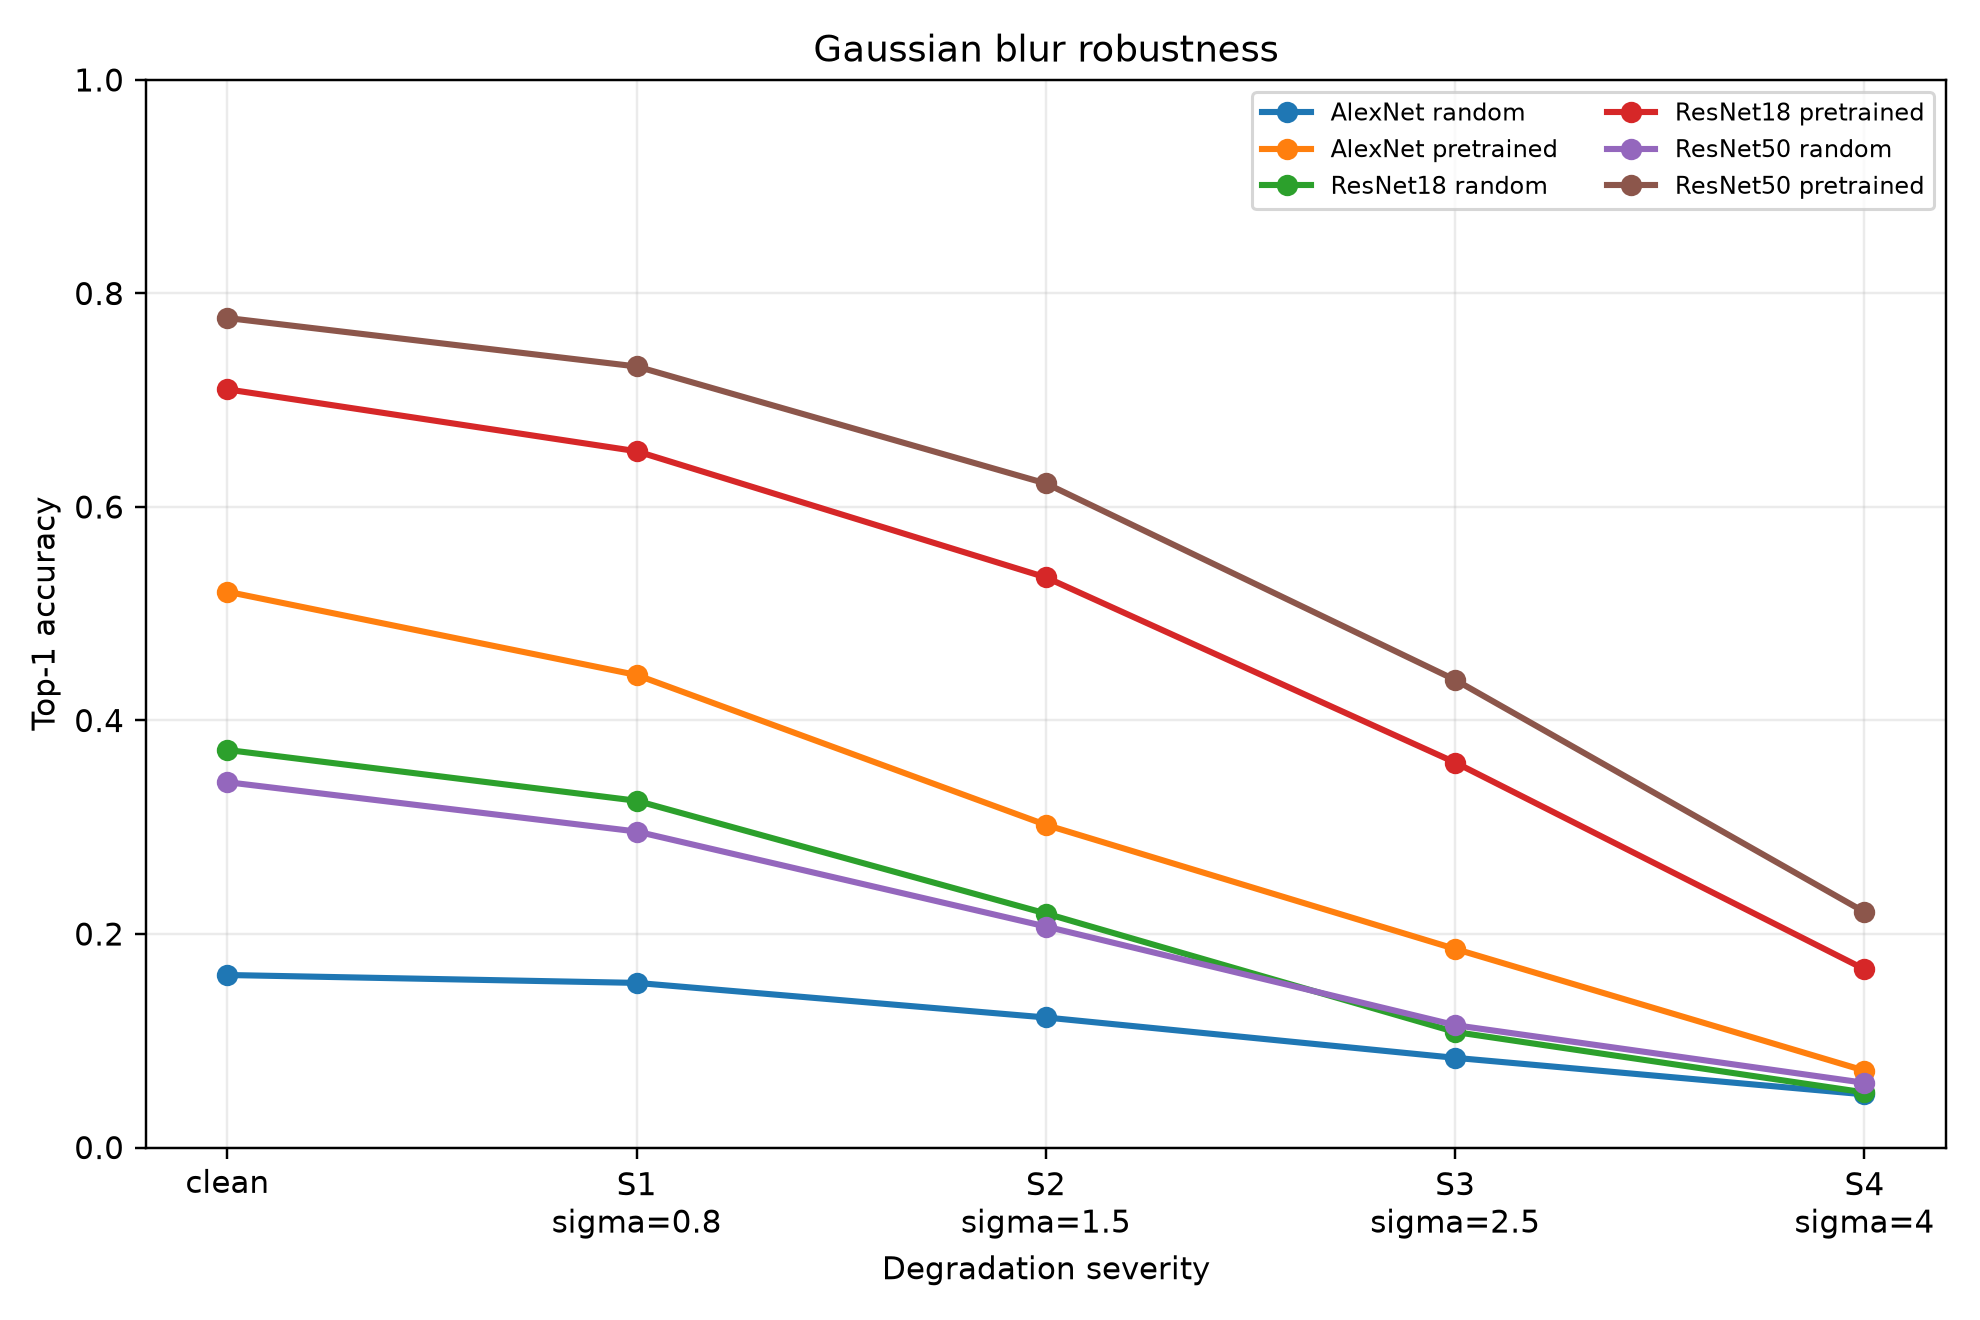

gaussian_noise_macro_f1


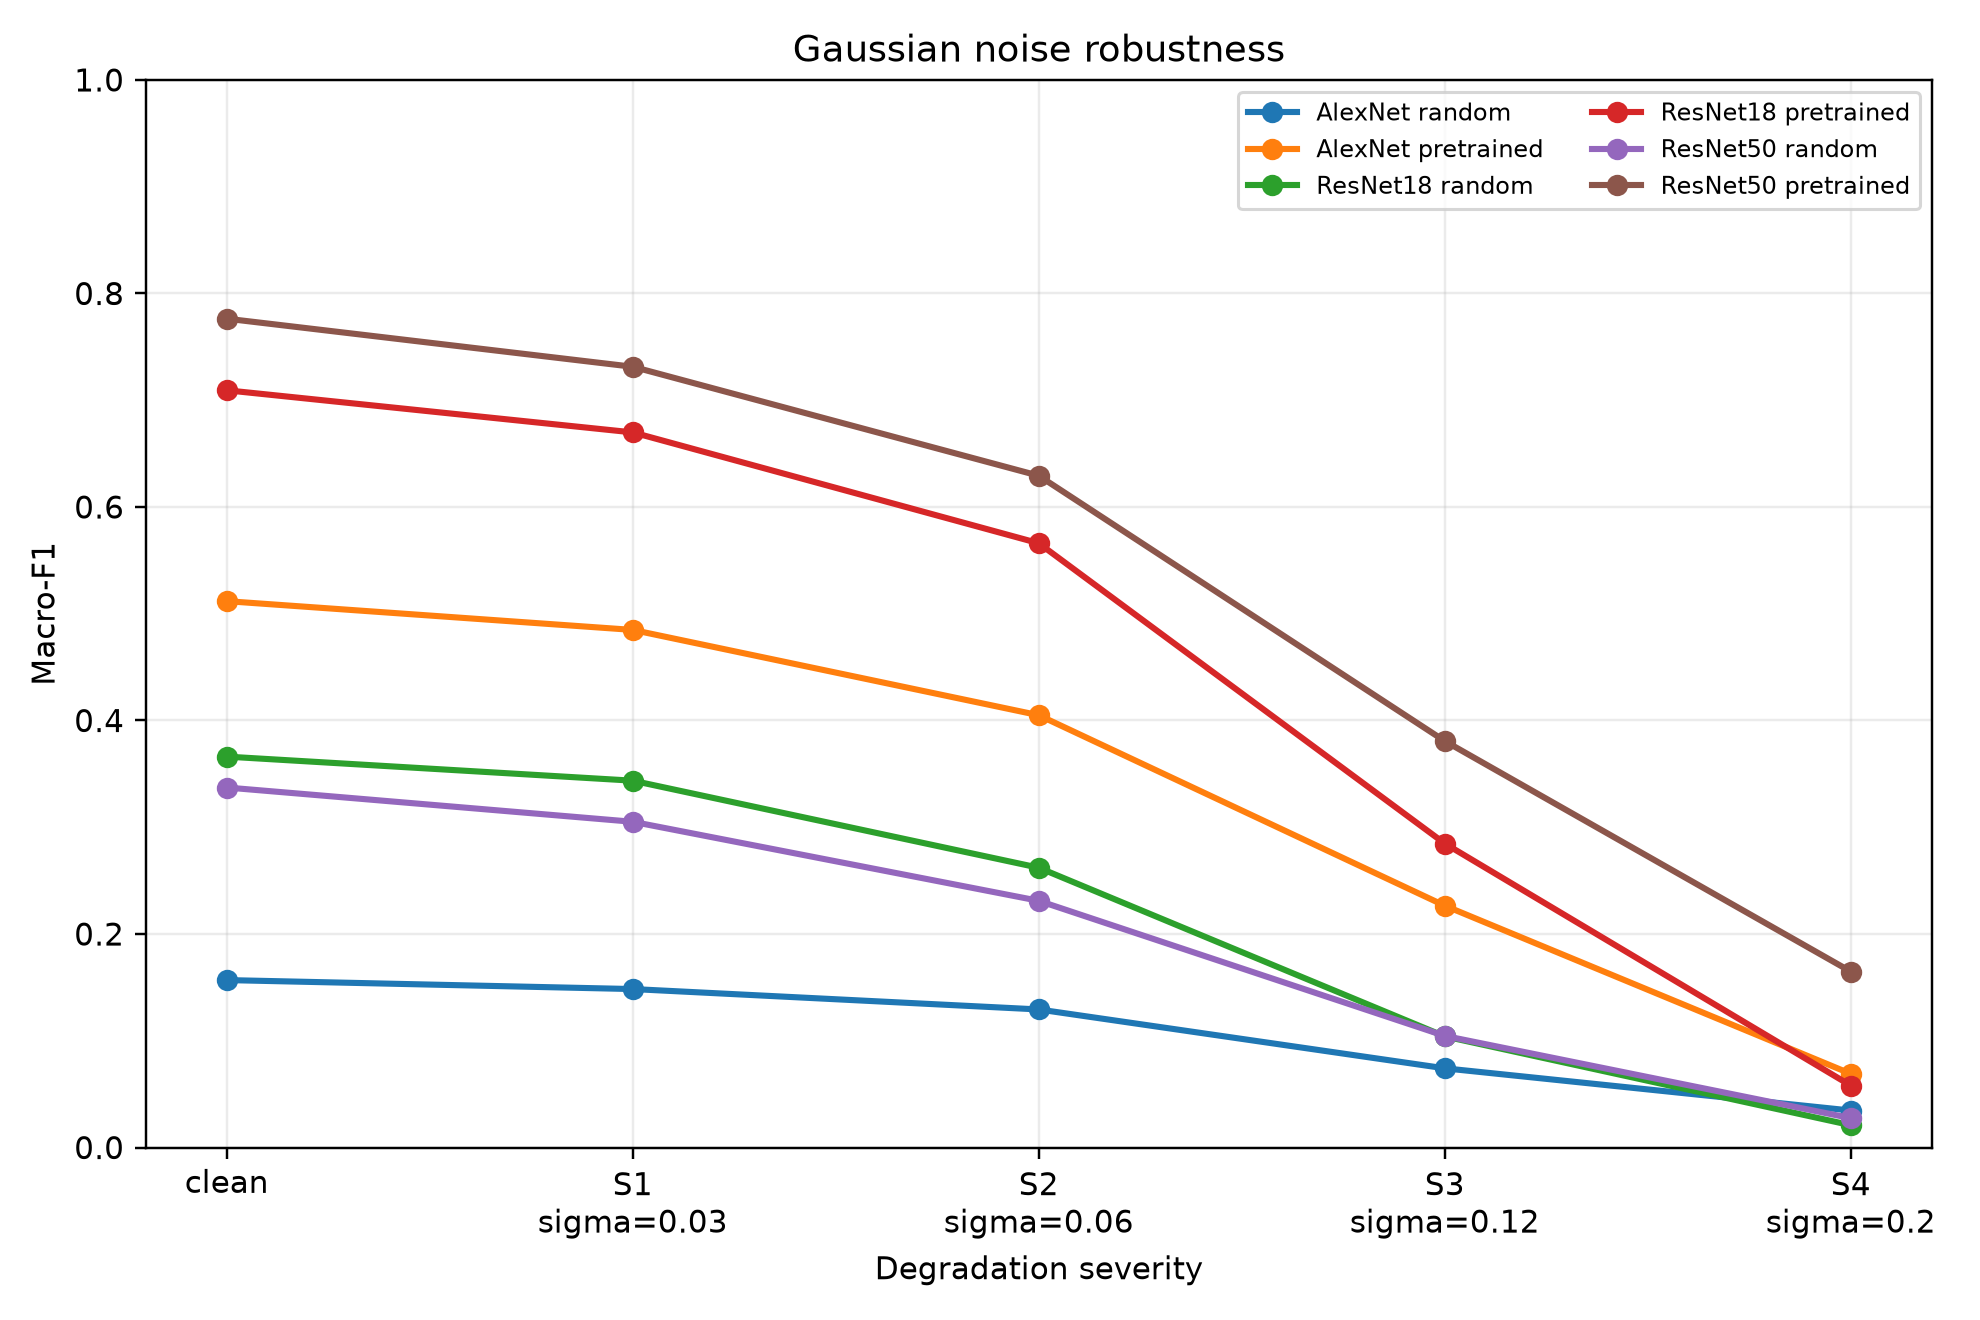

gaussian_noise_top1


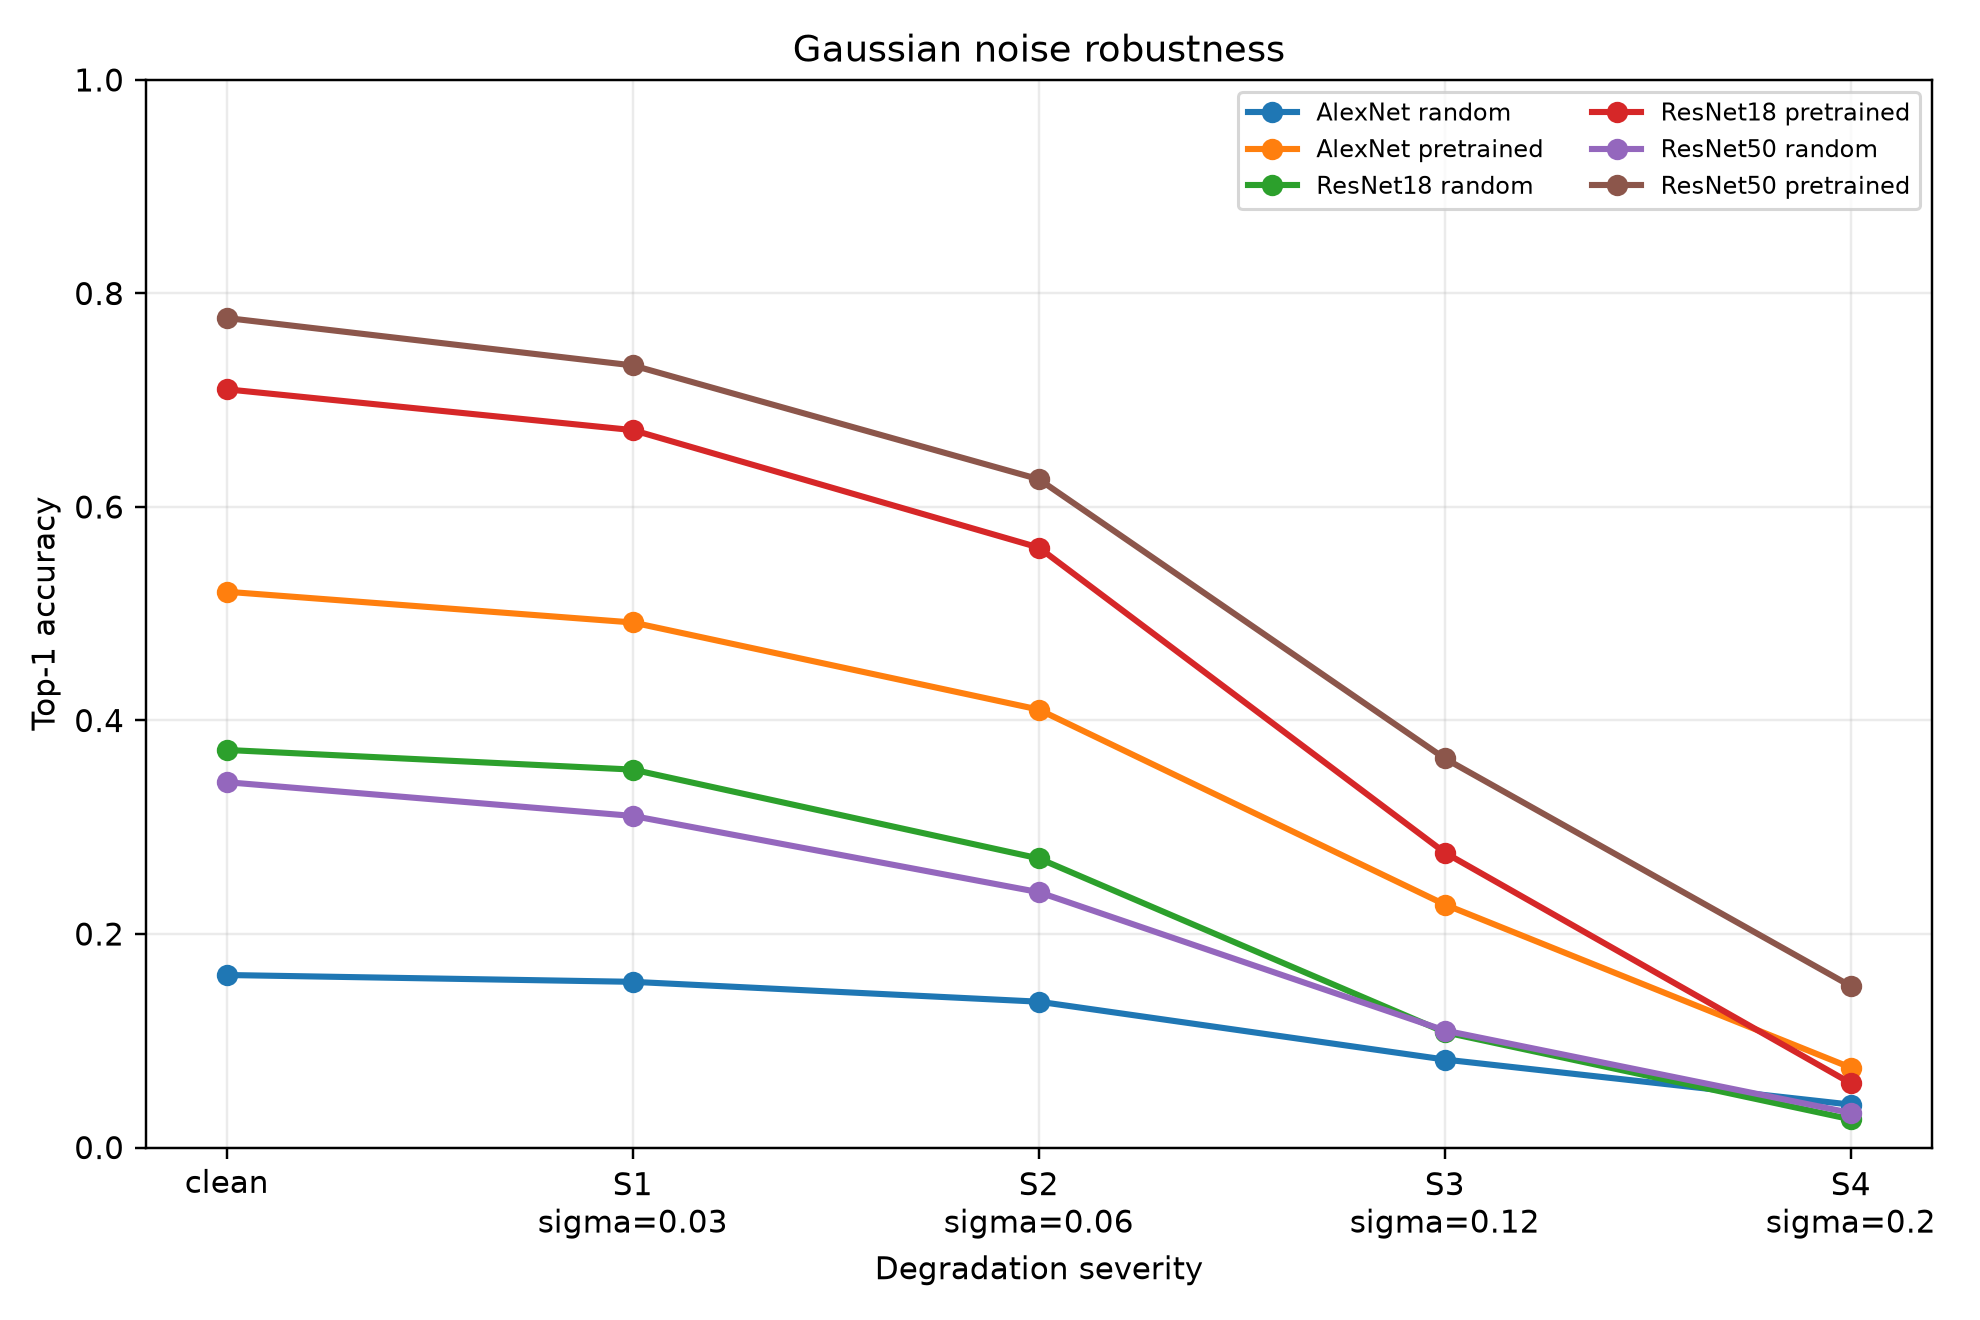

jpeg_compression_macro_f1


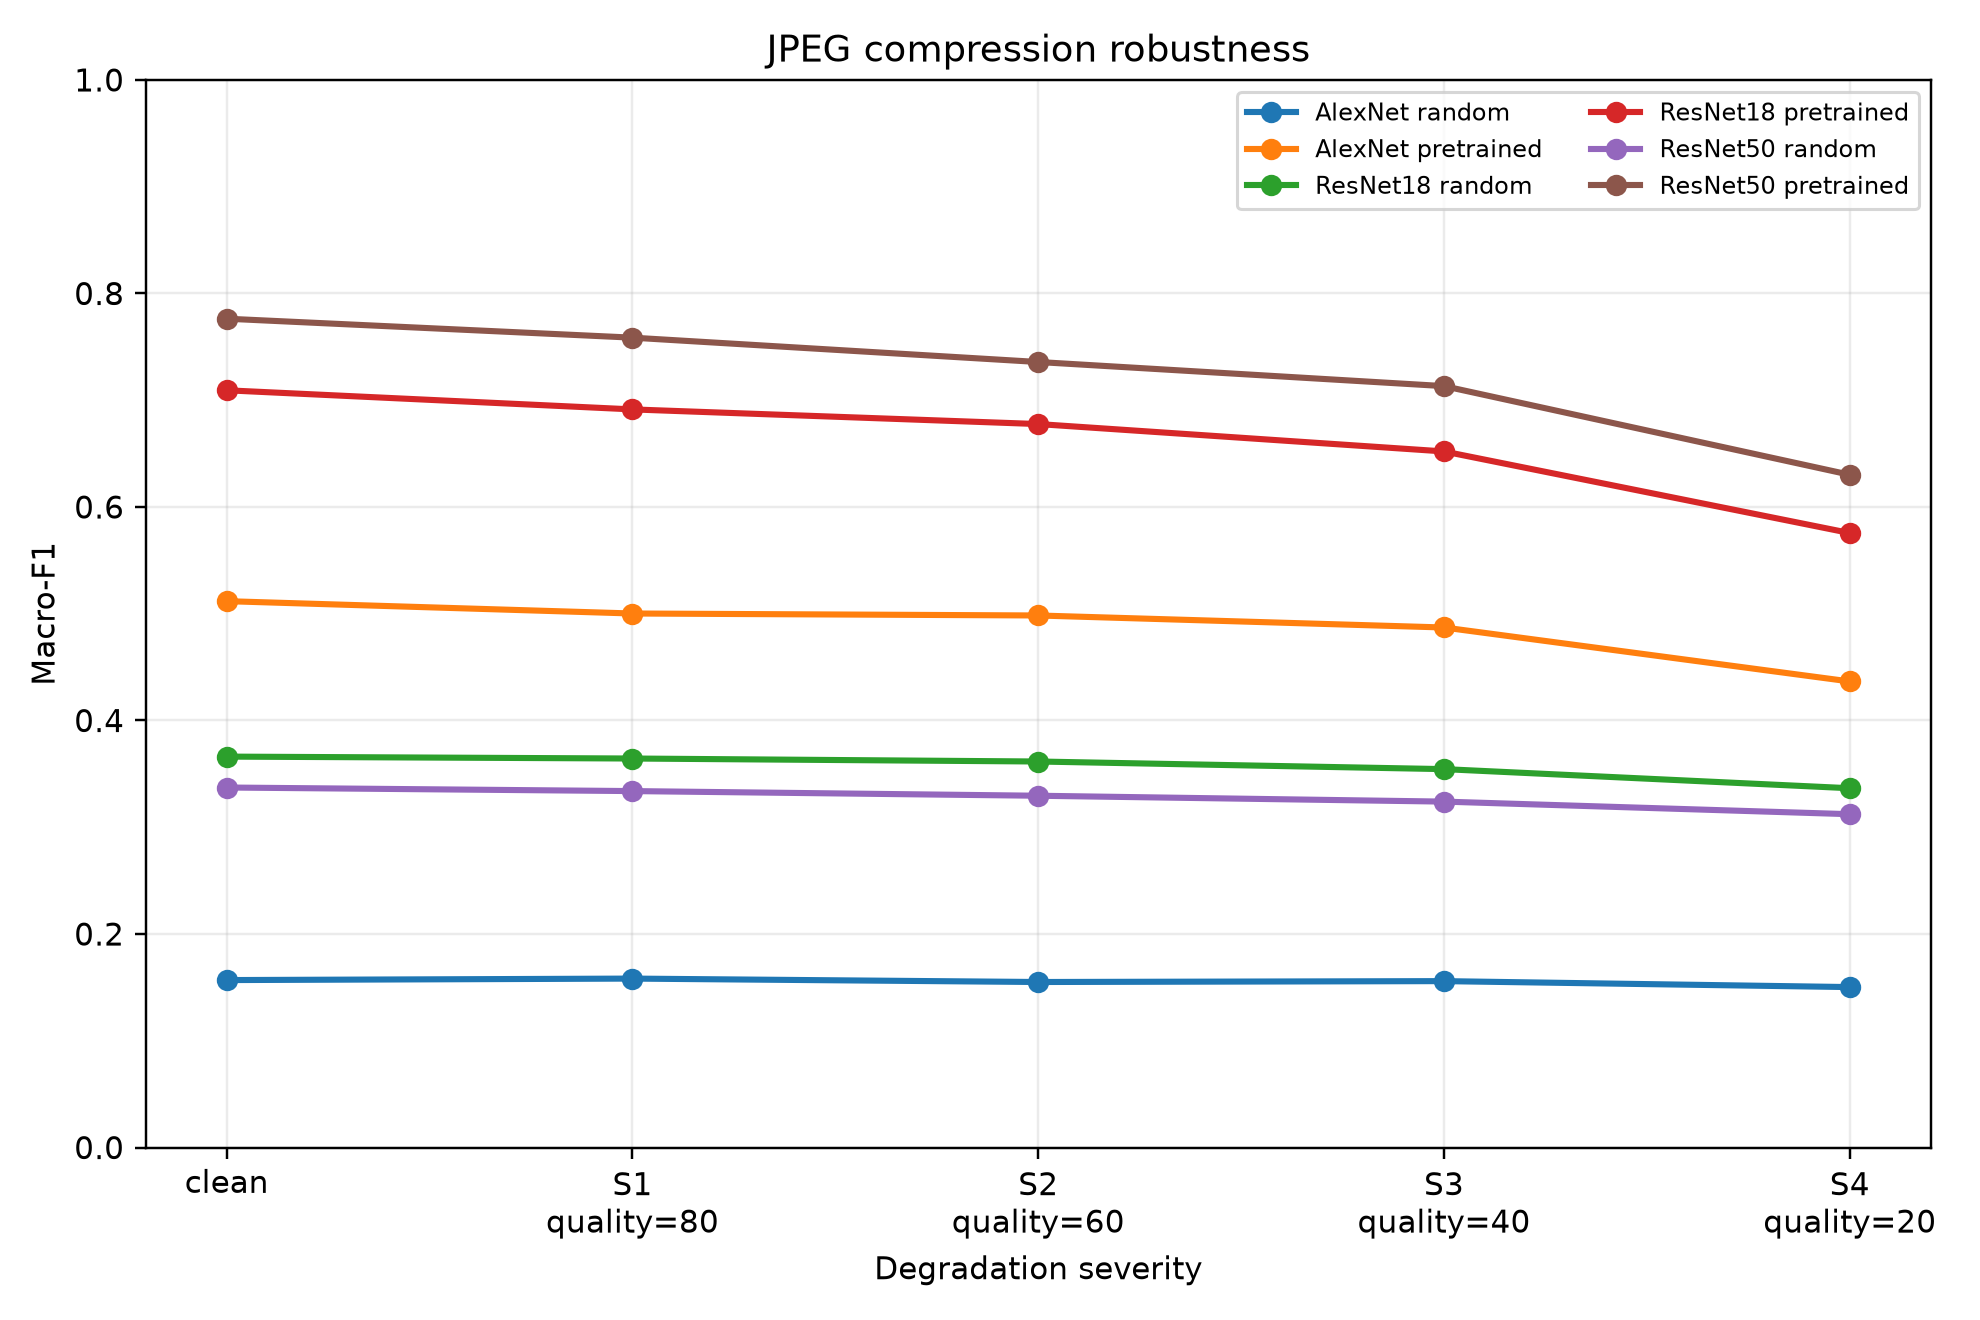

jpeg_compression_top1


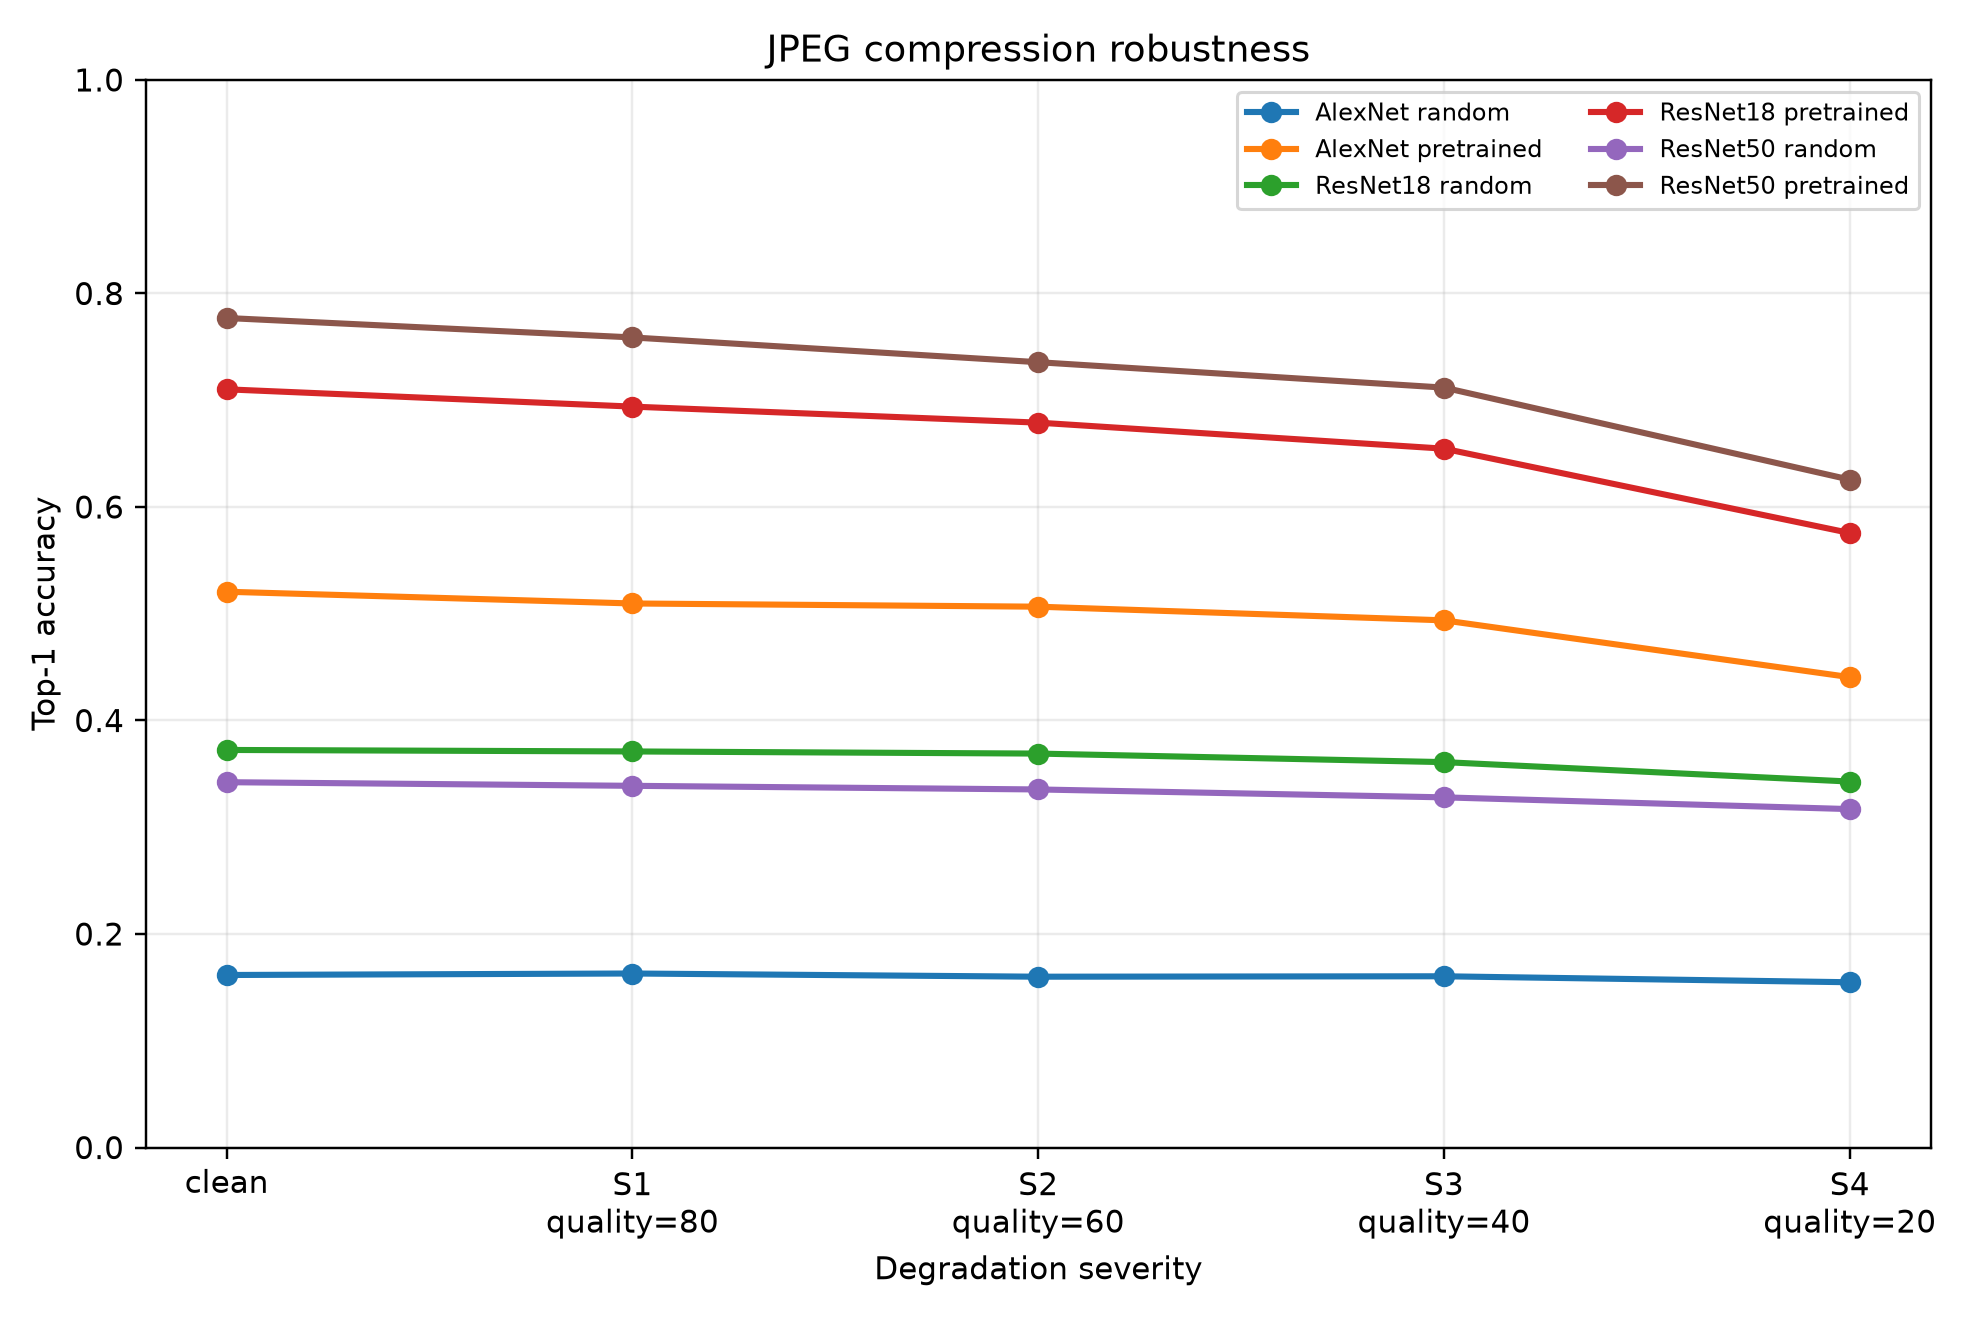

motion_blur_macro_f1


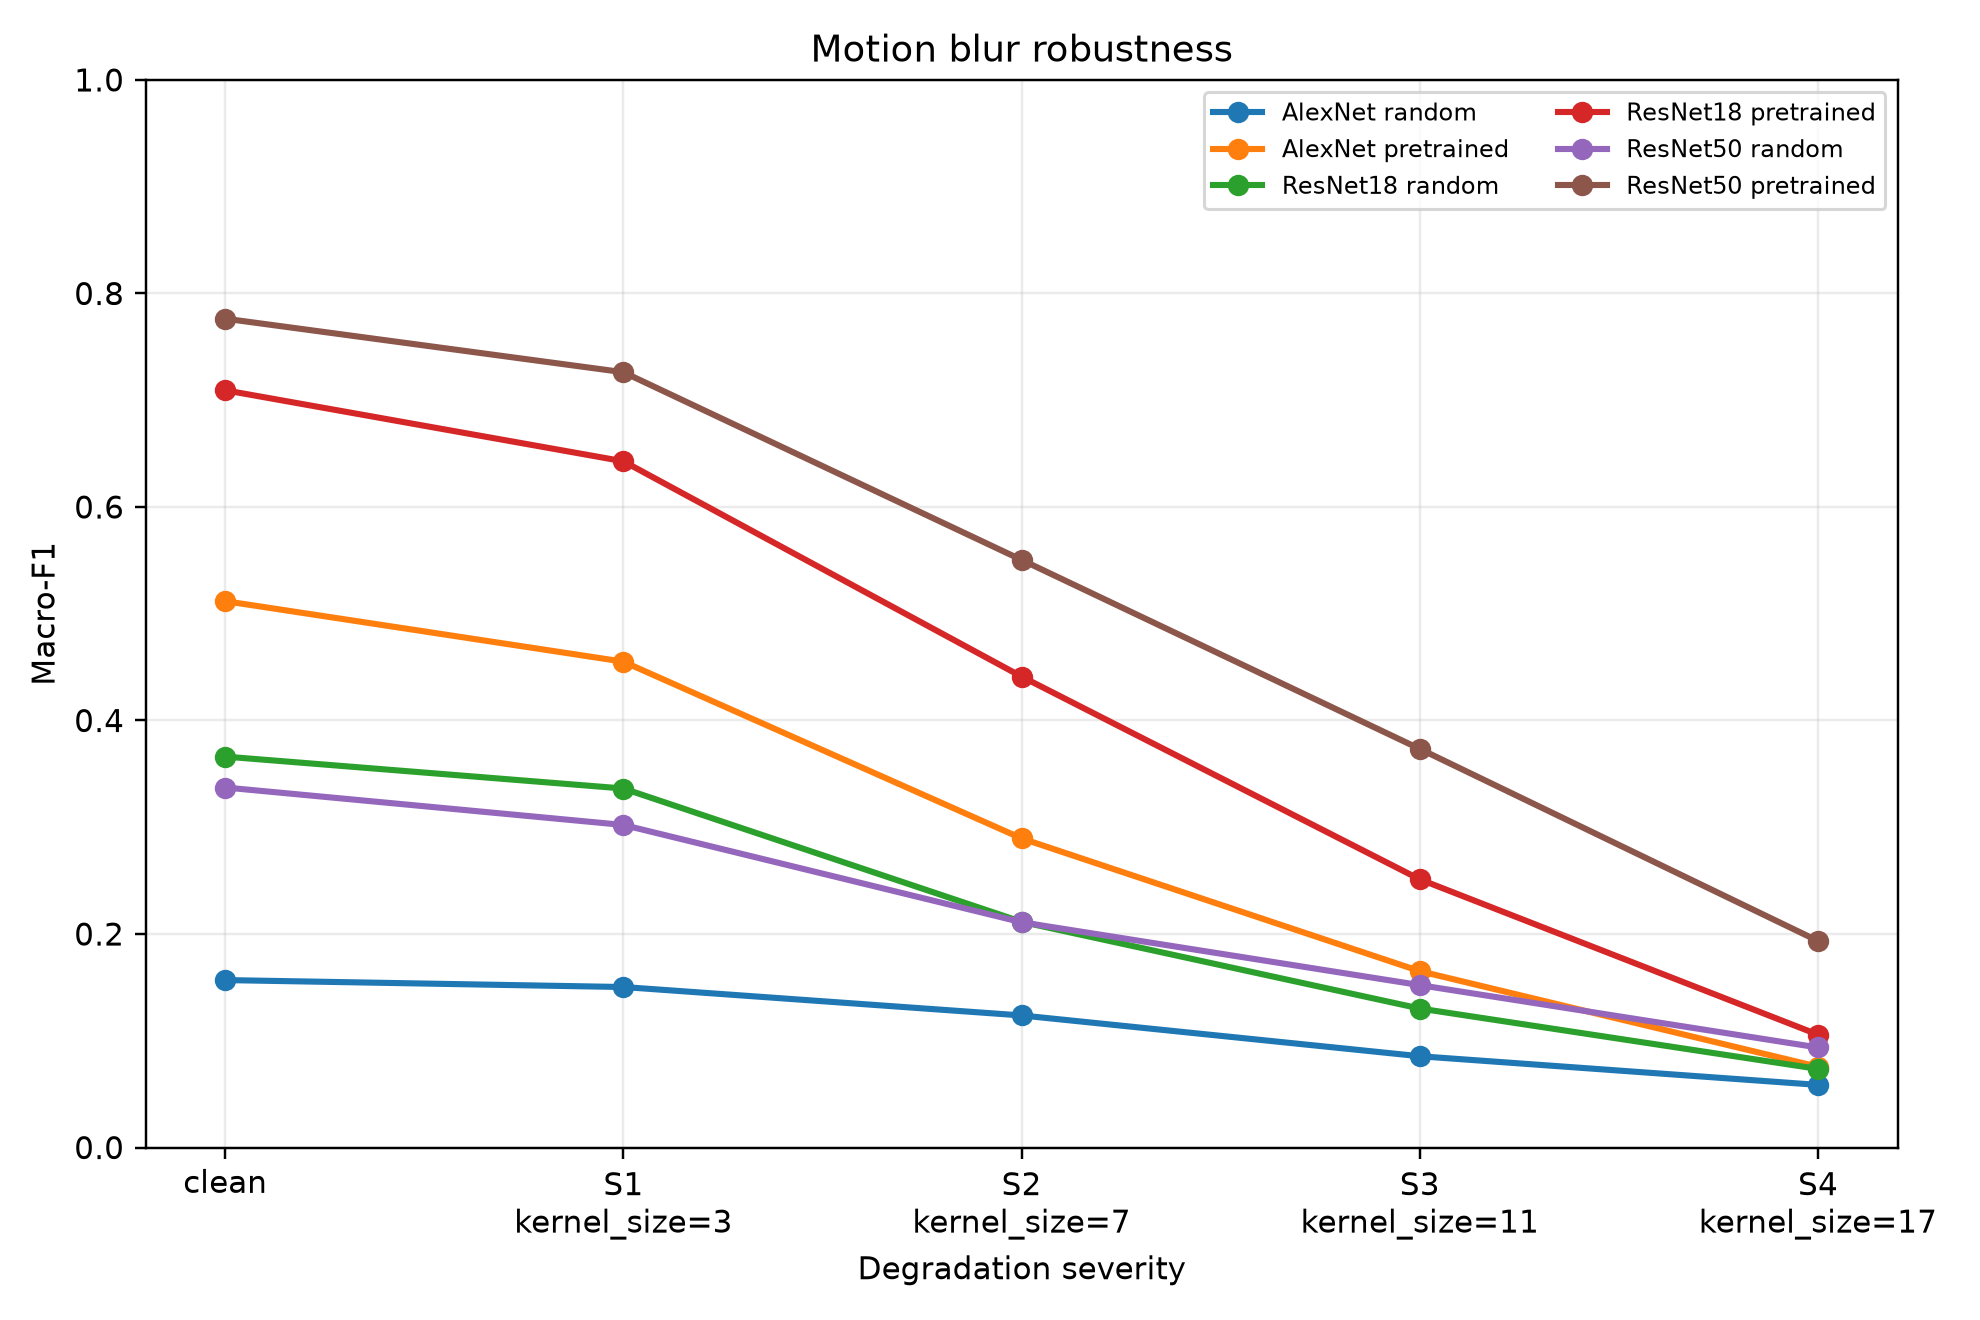

motion_blur_top1


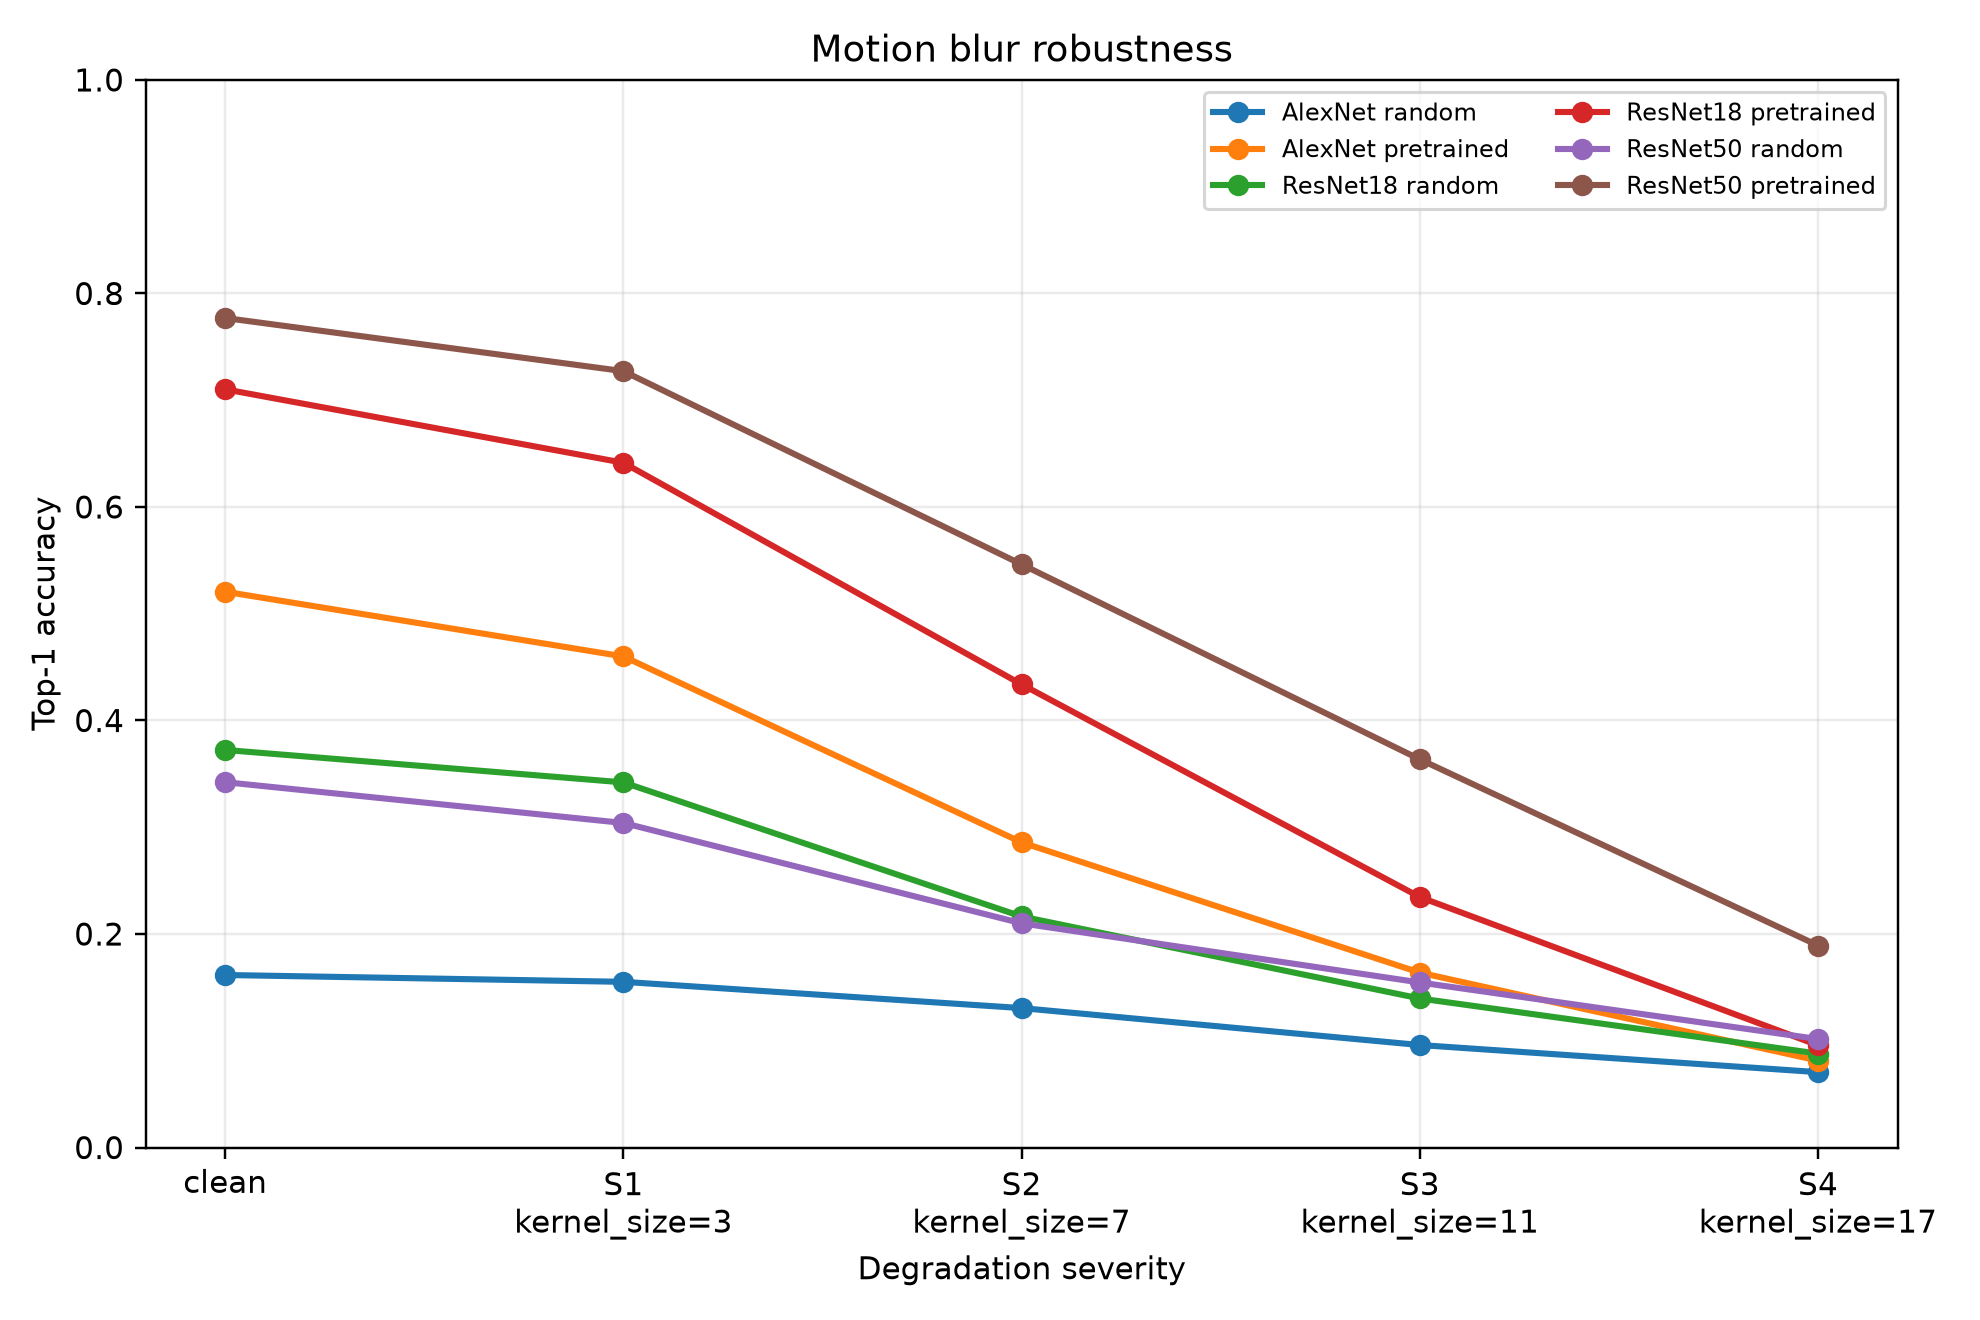

In [30]:
plots = sorted((analysis_dir / 'plots').glob('*.png'))
if len(plots) != 8:
    raise RuntimeError(f'Expected 8 performance curves, found {len(plots)}')
for path in plots:
    print(path.stem)
    display(Image.open(path))

## Main findings

- **ResNet50 pretrained is the strongest method in absolute terms:** clean Top-1 is 77.70%, and its mean Top-1 across all 16 corrupted conditions is 53.40%. ResNet18 pretrained ranks second at 45.58%, followed by AlexNet pretrained at 32.18%.
- **JPEG compression is least damaging:** even at quality 20, ResNet50 pretrained retains 62.56% Top-1.
- **High-severity blur and noise are destructive:** ResNet50 pretrained falls to 22.06% under Gaussian blur sigma 4, 18.92% under motion-blur kernel 17, and 15.12% under Gaussian-noise sigma 0.20.
- **Pretraining and deeper residual features improve absolute robustness:** the pretrained ResNets remain above the AlexNet variants across the degradation families. Residual hierarchies provide stronger multi-scale representations, but severe blur removes fine shape/texture cues and noise introduces spurious local responses that affect every model.
- **Relative retention must be interpreted carefully:** AlexNet random retains the largest fraction of its clean performance, but its clean Top-1 is only 16.16% and its mean corrupted Top-1 is 11.97%. It is therefore not the most useful robust model.

The motion-blur experiment uses a fixed horizontal direction, so the conclusions concern increasing blur length rather than rotation-invariant motion robustness.

## Interpretation checklist

Compare which degradation produces the steepest decline, whether pretrained models retain a consistent advantage, and whether deeper ResNet features help under blur and compression. Gaussian and motion blur remove high-frequency shape and texture information; noise introduces spurious local responses; JPEG compression removes fine detail and creates blocking artefacts. Relate these effects to AlexNet's shallower representation and the residual feature hierarchy in ResNet18/ResNet50. Do not claim that relative retention alone makes a low-accuracy model the best method.